# AMZN Hisse Senedi Fiyat Tahmini — LSTM & GRU

Bu notebook, Amazon (AMZN) hissesinin geçmiş kapanış fiyatları kullanılarak 
LSTM ve GRU mimarileriyle bir sonraki günün fiyatını tahmin etmeye çalışır.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [2]:
## 1. Veri Yükleme (Data Loading)

In [3]:
df = pd.read_csv("all_stocks_2006-01-01_to_2018-01-01.csv")
print("Veri seti boyutu:", df.shape)
df.head()

Veri seti boyutu: (93612, 7)


,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,77.76,79.35,77.24,79.11,3117200,MMM
1,2006-01-04,79.49,79.49,78.25,78.71,2558000,MMM
2,2006-01-05,78.41,78.65,77.56,77.99,2529500,MMM
3,2006-01-06,78.64,78.90,77.64,78.63,2479500,MMM
4,2006-01-09,78.50,79.83,78.46,79.02,1845600,MMM


In [4]:
# Sadece AMZN verisini filtrele
amzn = df[df['Name'] == 'AMZN'].copy()
amzn = amzn.sort_values('Date').reset_index(drop=True)

print("AMZN veri boyutu:", amzn.shape)
print("Tarih aralığı:", amzn['Date'].min(), "-", amzn['Date'].max())
amzn.head()

AMZN veri boyutu: (3019, 7)
Tarih aralığı: 2006-01-03 - 2017-12-29


,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


In [5]:
## 2. Keşifsel Veri Analizi (EDA)

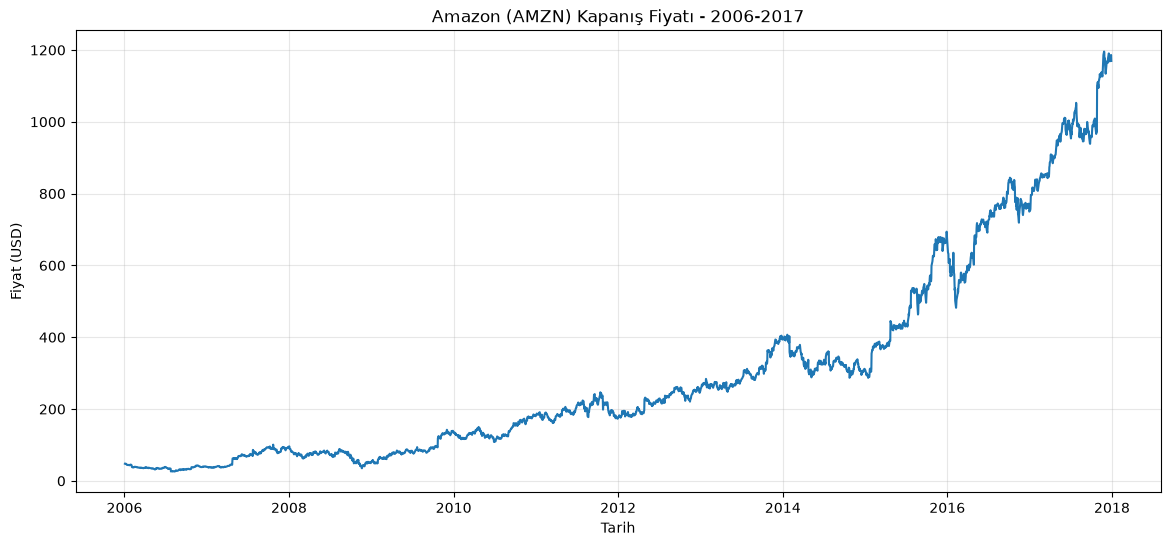

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(pd.to_datetime(amzn['Date']), amzn['Close'])
plt.title('Amazon (AMZN) Kapanış Fiyatı - 2006-2017')
plt.xlabel('Tarih')
plt.ylabel('Fiyat (USD)')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Veri Ön İşleme (Preprocessing)

Fiyatları normalize edip, sliding window yöntemiyle model girdisine uygun 
sekanslar oluşturuyoruz.

In [7]:
# Sadece Close fiyatını al
close_prices = amzn['Close'].values.reshape(-1, 1)

# 0-1 arasına normalize et
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("Normalize edilmiş veri boyutu:", scaled_data.shape)
print("İlk 5 değer:", scaled_data[:5].flatten())

Normalize edilmiş veri boyutu: (3019, 1)
İlk 5 değer: [0.01838839 0.01810628 0.01844823 0.0186363  0.01796095]


In [8]:
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 20
X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("X boyutu:", X.shape)  # (örnek sayısı, 20, 1)
print("y boyutu:", y.shape)  # (örnek sayısı, 1)

X boyutu: (2999, 20, 1)
y boyutu: (2999, 1)


In [9]:
# Zaman serisi olduğu için karıştırmadan (shuffle=False), kronolojik böl
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Eğitim seti:", X_train.shape, y_train.shape)
print("Test seti:", X_test.shape, y_test.shape)

Eğitim seti: (2399, 20, 1) (2399, 1)
Test seti: (600, 20, 1) (600, 1)


In [10]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print("PyTorch tensor boyutları:")
print("X_train:", X_train_t.shape)
print("y_train:", y_train_t.shape)

PyTorch tensor boyutları:
X_train: torch.Size([2399, 20, 1])
y_train: torch.Size([2399, 1])


In [11]:
## 4. Model Tanımları (Model Definition)

In [12]:
class LSTMModel(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # sadece son zaman adımını al
        return out

lstm_model = LSTMModel()
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### İlk Deneme (Baseline)

İlk denemede daha küçük bir modelle (hidden_size=50, 50 epoch) başladık. 
Loss yeterince düşmedi, aşağıda hiperparametreleri artırarak (hidden_size=64, 
200 epoch) yeniden eğittik.

In [13]:
# Loss fonksiyonu ve optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# Eğitim döngüsü
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    lstm_model.train()
    optimizer.zero_grad()
    
    outputs = lstm_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

print("\nEğitim tamamlandı!")

Epoch [5/50], Loss: 0.057883
Epoch [10/50], Loss: 0.021510
Epoch [15/50], Loss: 0.010189
Epoch [20/50], Loss: 0.014605
Epoch [25/50], Loss: 0.009504
Epoch [30/50], Loss: 0.009851
Epoch [35/50], Loss: 0.010071
Epoch [40/50], Loss: 0.009196
Epoch [45/50], Loss: 0.008696
Epoch [50/50], Loss: 0.008648

Eğitim tamamlandı!


### Hiperparametre Artırılmış Final LSTM Eğitimi

Bu, karşılaştırmalarda kullanacağımız asıl LSTM modelidir.

In [14]:
# Modeli sıfırdan tekrar oluştur (önceki eğitimden etkilenmesin)
lstm_model = LSTMModel(hidden_size=64, num_layers=2)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

num_epochs = 200
train_losses = []

for epoch in range(num_epochs):
    lstm_model.train()
    optimizer.zero_grad()
    
    outputs = lstm_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

print("\nEğitim tamamlandı!")

Epoch [20/200], Loss: 0.005810
Epoch [40/200], Loss: 0.002497
Epoch [60/200], Loss: 0.000190
Epoch [80/200], Loss: 0.000159
Epoch [100/200], Loss: 0.000092
Epoch [120/200], Loss: 0.000073
Epoch [140/200], Loss: 0.000063
Epoch [160/200], Loss: 0.000056
Epoch [180/200], Loss: 0.000052
Epoch [200/200], Loss: 0.000049

Eğitim tamamlandı!


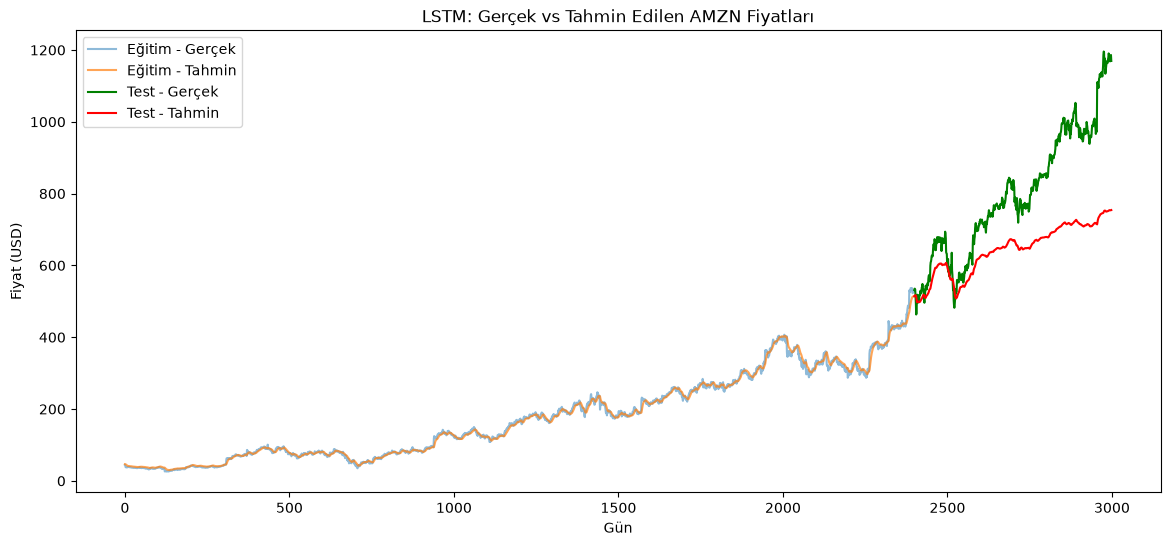

In [15]:
lstm_model.eval()
with torch.no_grad():
    train_pred = lstm_model(X_train_t)
    test_pred = lstm_model(X_test_t)

# Normalize edilmiş veriyi gerçek fiyat ölçeğine geri çevir
train_pred_actual = scaler.inverse_transform(train_pred.numpy())
test_pred_actual = scaler.inverse_transform(test_pred.numpy())
y_train_actual = scaler.inverse_transform(y_train_t.numpy())
y_test_actual = scaler.inverse_transform(y_test_t.numpy())

# Grafik
plt.figure(figsize=(14, 6))
plt.plot(range(len(y_train_actual)), y_train_actual, label='Eğitim - Gerçek', alpha=0.5)
plt.plot(range(len(y_train_actual)), train_pred_actual, label='Eğitim - Tahmin', alpha=0.7)
plt.plot(range(len(y_train_actual), len(y_train_actual)+len(y_test_actual)), y_test_actual, label='Test - Gerçek', color='green')
plt.plot(range(len(y_train_actual), len(y_train_actual)+len(y_test_actual)), test_pred_actual, label='Test - Tahmin', color='red')
plt.legend()
plt.title('LSTM: Gerçek vs Tahmin Edilen AMZN Fiyatları')
plt.xlabel('Gün')
plt.ylabel('Fiyat (USD)')
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

lstm_train_mse = mean_squared_error(y_train_actual, train_pred_actual)
lstm_test_mse = mean_squared_error(y_test_actual, test_pred_actual)
lstm_train_rmse = np.sqrt(lstm_train_mse)
lstm_test_rmse = np.sqrt(lstm_test_mse)

print("=== LSTM Sonuçları ===")
print(f"Eğitim MSE: {lstm_train_mse:.4f}, RMSE: {lstm_train_rmse:.4f}")
print(f"Test MSE: {lstm_test_mse:.4f}, RMSE: {lstm_test_rmse:.4f}")

=== LSTM Sonuçları ===
Eğitim MSE: 66.2698, RMSE: 8.1406
Test MSE: 35835.5117, RMSE: 189.3027


In [17]:
## 5. GRU Modeli

In [18]:
class GRUModel(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = torch.nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

gru_model = GRUModel(hidden_size=64, num_layers=2)
print(gru_model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [19]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.01)

num_epochs = 200
gru_train_losses = []

for epoch in range(num_epochs):
    gru_model.train()
    optimizer.zero_grad()
    
    outputs = gru_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    gru_train_losses.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

print("\nGRU eğitimi tamamlandı!")

Epoch [20/200], Loss: 0.004229
Epoch [40/200], Loss: 0.000231
Epoch [60/200], Loss: 0.000034
Epoch [80/200], Loss: 0.000021
Epoch [100/200], Loss: 0.000020
Epoch [120/200], Loss: 0.000019
Epoch [140/200], Loss: 0.000018
Epoch [160/200], Loss: 0.000017
Epoch [180/200], Loss: 0.000017
Epoch [200/200], Loss: 0.000017

GRU eğitimi tamamlandı!


In [20]:
gru_model.eval()
with torch.no_grad():
    gru_train_pred = gru_model(X_train_t)
    gru_test_pred = gru_model(X_test_t)

gru_train_pred_actual = scaler.inverse_transform(gru_train_pred.numpy())
gru_test_pred_actual = scaler.inverse_transform(gru_test_pred.numpy())

gru_train_mse = mean_squared_error(y_train_actual, gru_train_pred_actual)
gru_test_mse = mean_squared_error(y_test_actual, gru_test_pred_actual)
gru_train_rmse = np.sqrt(gru_train_mse)
gru_test_rmse = np.sqrt(gru_test_mse)

print("=== GRU Sonuçları ===")
print(f"Eğitim MSE: {gru_train_mse:.4f}, RMSE: {gru_train_rmse:.4f}")
print(f"Test MSE: {gru_test_mse:.4f}, RMSE: {gru_test_rmse:.4f}")

=== GRU Sonuçları ===
Eğitim MSE: 23.0621, RMSE: 4.8023
Test MSE: 1591.0798, RMSE: 39.8883


In [21]:
## 6. LSTM vs GRU Karşılaştırması

In [22]:
print("=" * 50)
print(f"{'Model':<10}{'Eğitim RMSE':<15}{'Test RMSE':<15}")
print("=" * 50)
print(f"{'LSTM':<10}{lstm_train_rmse:<15.4f}{lstm_test_rmse:<15.4f}")
print(f"{'GRU':<10}{gru_train_rmse:<15.4f}{gru_test_rmse:<15.4f}")

Model     Eğitim RMSE    Test RMSE      
LSTM      8.1406         189.3027       
GRU       4.8023         39.8883        


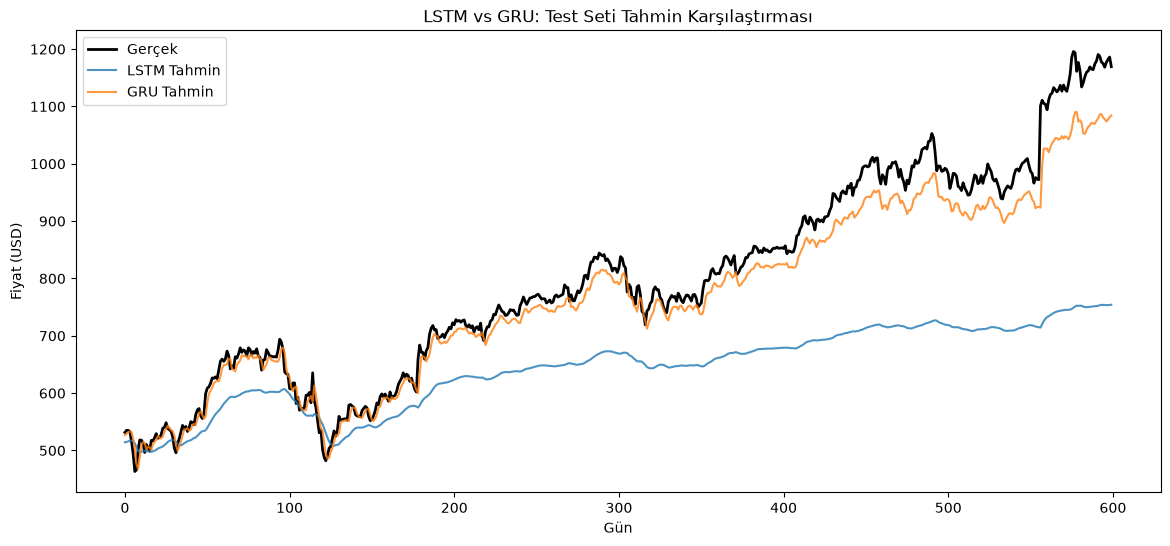

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(range(len(y_test_actual)), y_test_actual, label='Gerçek', color='black', linewidth=2)
plt.plot(range(len(y_test_actual)), test_pred_actual, label='LSTM Tahmin', alpha=0.8)
plt.plot(range(len(y_test_actual)), gru_test_pred_actual, label='GRU Tahmin', alpha=0.8)
plt.legend()
plt.title('LSTM vs GRU: Test Seti Tahmin Karşılaştırması')
plt.xlabel('Gün')
plt.ylabel('Fiyat (USD)')
plt.show()

In [24]:
## Getiri (Return) Bazlı Yaklaşım — Non-Stationarity Sorununu Çözme

In [25]:
# Günlük yüzde değişim (return) hesapla
amzn['Return'] = amzn['Close'].pct_change()
amzn = amzn.dropna().reset_index(drop=True)  # ilk satır NaN olur, at

print(amzn[['Date', 'Close', 'Return']].head())
print("\nReturn istatistikleri:")
print(amzn['Return'].describe())

         Date  Close    Return
0  2006-01-04  47.25 -0.006936
1  2006-01-05  47.65  0.008466
2  2006-01-06  47.87  0.004617
3  2006-01-09  47.08 -0.016503
4  2006-01-10  45.65 -0.030374

Return istatistikleri:
count    3018.000000
mean        0.001374
std         0.025209
min        -0.218220
25%        -0.009899
50%         0.000414
75%         0.012484
max         0.269497
Name: Return, dtype: float64


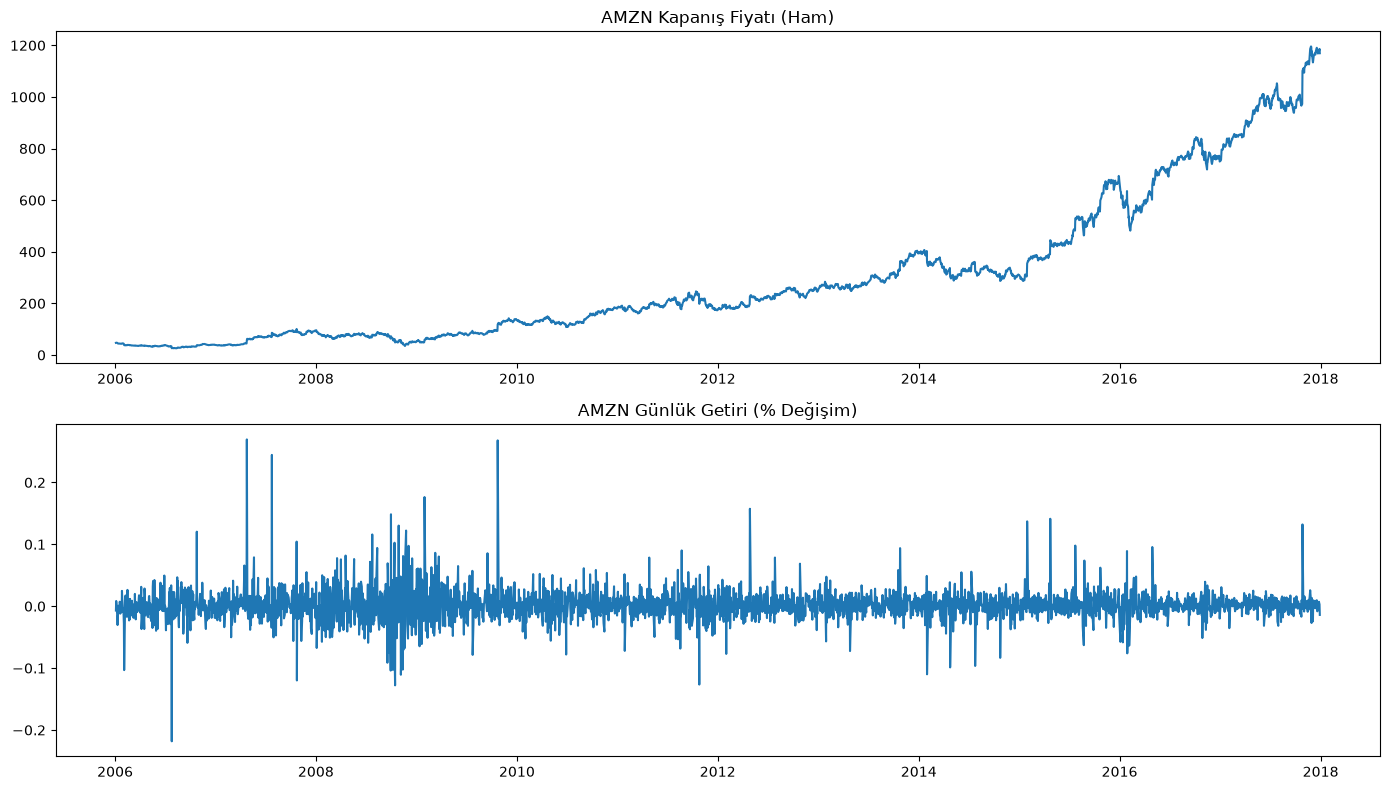

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(pd.to_datetime(amzn['Date']), amzn['Close'])
axes[0].set_title('AMZN Kapanış Fiyatı (Ham)')
axes[1].plot(pd.to_datetime(amzn['Date']), amzn['Return'])
axes[1].set_title('AMZN Günlük Getiri (% Değişim)')
plt.tight_layout()
plt.show()

In [27]:
returns = amzn['Return'].values.reshape(-1, 1)

# Önce train/test'e ayır (ham return üzerinden)
train_size_r = int(len(returns) * 0.8)
train_raw_r, test_raw_r = returns[:train_size_r], returns[train_size_r:]

# Scaler'ı SADECE train ile fit et
return_scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled_r = return_scaler.fit_transform(train_raw_r)
test_scaled_r = return_scaler.transform(test_raw_r)

print("Train:", train_scaled_r.shape, "Test:", test_scaled_r.shape)

Train: (2414, 1) Test: (604, 1)


In [28]:
X_train_r, y_train_r = create_sequences(train_scaled_r, WINDOW_SIZE)
X_test_r, y_test_r = create_sequences(test_scaled_r, WINDOW_SIZE)

print("X_train_r:", X_train_r.shape, "X_test_r:", X_test_r.shape)

X_train_rt = torch.FloatTensor(X_train_r)
y_train_rt = torch.FloatTensor(y_train_r)
X_test_rt = torch.FloatTensor(X_test_r)
y_test_rt = torch.FloatTensor(y_test_r)

X_train_r: (2394, 20, 1) X_test_r: (584, 20, 1)


In [29]:
lstm_model_r = LSTMModel(hidden_size=64, num_layers=2)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model_r.parameters(), lr=0.01)

num_epochs = 200
for epoch in range(num_epochs):
    lstm_model_r.train()
    optimizer.zero_grad()
    outputs = lstm_model_r(X_train_rt)
    loss = criterion(outputs, y_train_rt)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

Epoch [20/200], Loss: 0.012501
Epoch [40/200], Loss: 0.012257
Epoch [60/200], Loss: 0.012230
Epoch [80/200], Loss: 0.012224
Epoch [100/200], Loss: 0.012220
Epoch [120/200], Loss: 0.012215
Epoch [140/200], Loss: 0.012208
Epoch [160/200], Loss: 0.012195
Epoch [180/200], Loss: 0.012175
Epoch [200/200], Loss: 0.012157


In [30]:
gru_model_r = GRUModel(hidden_size=64, num_layers=2)
optimizer = torch.optim.Adam(gru_model_r.parameters(), lr=0.01)

for epoch in range(num_epochs):
    gru_model_r.train()
    optimizer.zero_grad()
    outputs = gru_model_r(X_train_rt)
    loss = criterion(outputs, y_train_rt)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

Epoch [20/200], Loss: 0.012340
Epoch [40/200], Loss: 0.012199
Epoch [60/200], Loss: 0.012169
Epoch [80/200], Loss: 0.012136
Epoch [100/200], Loss: 0.012099
Epoch [120/200], Loss: 0.012063
Epoch [140/200], Loss: 0.011992
Epoch [160/200], Loss: 0.011807
Epoch [180/200], Loss: 0.011361
Epoch [200/200], Loss: 0.010827


In [31]:
def evaluate_returns(model, X_train_t, y_train_t, X_test_t, y_test_t, scaler):
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t)
        test_pred = model(X_test_t)

    train_pred_inv = scaler.inverse_transform(train_pred.numpy())
    test_pred_inv = scaler.inverse_transform(test_pred.numpy())
    y_train_inv = scaler.inverse_transform(y_train_t.numpy())
    y_test_inv = scaler.inverse_transform(y_test_t.numpy())

    train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
    return train_rmse, test_rmse

lstm_train_rmse_r, lstm_test_rmse_r = evaluate_returns(lstm_model_r, X_train_rt, y_train_rt, X_test_rt, y_test_rt, return_scaler)
gru_train_rmse_r, gru_test_rmse_r = evaluate_returns(gru_model_r, X_train_rt, y_train_rt, X_test_rt, y_test_rt, return_scaler)

print("=== Getiri (Return) Bazlı Sonuçlar ===")
print(f"LSTM -> Train RMSE: {lstm_train_rmse_r:.6f}, Test RMSE: {lstm_test_rmse_r:.6f}")
print(f"GRU  -> Train RMSE: {gru_train_rmse_r:.6f}, Test RMSE: {gru_test_rmse_r:.6f}")

=== Getiri (Return) Bazlı Sonuçlar ===
LSTM -> Train RMSE: 0.026887, Test RMSE: 0.016449
GRU  -> Train RMSE: 0.025865, Test RMSE: 0.016402


In [32]:
print("=" * 65)
print(f"{'Yaklaşım':<20}{'Model':<8}{'Train RMSE':<15}{'Test RMSE':<15}")
print("=" * 65)
print(f"{'Ham Fiyat':<20}{'LSTM':<8}{lstm_train_rmse:<15.4f}{lstm_test_rmse:<15.4f}")
print(f"{'Ham Fiyat':<20}{'GRU':<8}{gru_train_rmse:<15.4f}{gru_test_rmse:<15.4f}")
print(f"{'Getiri (Return)':<20}{'LSTM':<8}{lstm_train_rmse_r:<15.6f}{lstm_test_rmse_r:<15.6f}")
print(f"{'Getiri (Return)':<20}{'GRU':<8}{gru_train_rmse_r:<15.6f}{gru_test_rmse_r:<15.6f}")

Yaklaşım            Model   Train RMSE     Test RMSE      
Ham Fiyat           LSTM    8.1406         189.3027       
Ham Fiyat           GRU     4.8023         39.8883        
Getiri (Return)     LSTM    0.026887       0.016449       
Getiri (Return)     GRU     0.025865       0.016402       


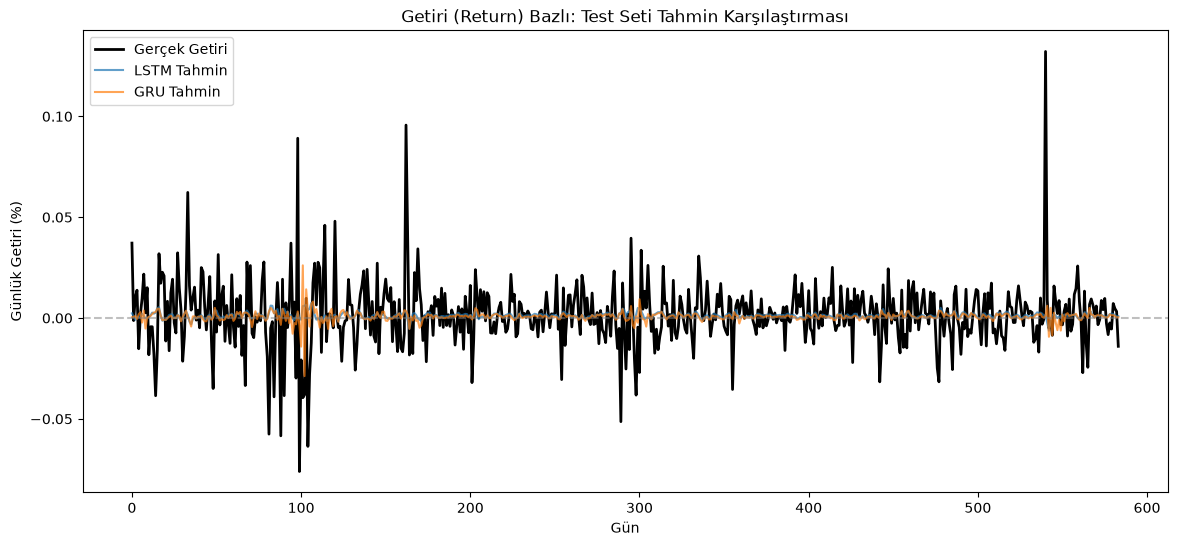

In [33]:
# Return modelinin test tahminlerini gerçek fiyata çevirip görselleştir
lstm_model_r.eval()
gru_model_r.eval()
with torch.no_grad():
    lstm_test_pred_r = lstm_model_r(X_test_rt)
    gru_test_pred_r = gru_model_r(X_test_rt)

lstm_test_pred_r_inv = return_scaler.inverse_transform(lstm_test_pred_r.numpy())
gru_test_pred_r_inv = return_scaler.inverse_transform(gru_test_pred_r.numpy())
y_test_r_inv = return_scaler.inverse_transform(y_test_rt.numpy())

plt.figure(figsize=(14, 6))
plt.plot(range(len(y_test_r_inv)), y_test_r_inv, label='Gerçek Getiri', color='black', linewidth=2)
plt.plot(range(len(y_test_r_inv)), lstm_test_pred_r_inv, label='LSTM Tahmin', alpha=0.7)
plt.plot(range(len(y_test_r_inv)), gru_test_pred_r_inv, label='GRU Tahmin', alpha=0.7)
plt.legend()
plt.title('Getiri (Return) Bazlı: Test Seti Tahmin Karşılaştırması')
plt.xlabel('Gün')
plt.ylabel('Günlük Getiri (%)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

## Bulgu: Non-Stationarity Sorunu ve Çözümü

Ham fiyat verisiyle eğitilen modellerde eğitim ve test hatası arasında büyük bir uçurum gözlemlendi 
(LSTM için ~13x, GRU için ~7x). Bunun nedeni, AMZN hissesinin 2006-2017 arasında fiyat seviyesinin 
kökten değişmesi (~$47'den ~$1170'e) — model, eğitim döneminde görmediği bir fiyat aralığında test 
edildiğinde büyük hata veriyor.

Bu sorunu çözmek için ham fiyat yerine **günlük getiri (% değişim)** üzerinden tahmin yapan bir 
model kurduk. Getiri serisi, fiyat seviyesinden bağımsız olarak daha durağan (stationary) bir 
yapıya sahip. Sonuç olarak train/test RMSE oranı normale döndü — hatta test hatası eğitim 
hatasından bile düşük çıktı, bu da modelin belirli bir fiyat aralığına aşırı uyum sağlamadığını gösteriyor.

Ayrıca, ham fiyat yaklaşımında scaler'ı **tüm veri üzerinde** (train+test) fit ettiğimiz için hafif 
bir veri sızıntısı (data leakage) vardı; return yaklaşımında scaler'ı sadece train verisiyle fit edip 
test'e sadece transform uyguladık, bu da metodolojik olarak daha doğru bir karşılaştırma sağladı.

**Model karşılaştırması:** Getiri bazlı yaklaşımda LSTM ve GRU neredeyse aynı performansı gösterdi 
(Test RMSE: 0.0164 vs 0.0164), ham fiyat yaklaşımında GRU'nun görülen üstünlüğü return uzayında 
ortadan kalktı.

In [34]:
# Çoklu özellik seti oluştur
features = ['Open', 'High', 'Low', 'Close', 'Volume']
amzn_multi = amzn[features].copy()

# Return'ü de bir özellik olarak ekle (Close'dan hesaplanan)
amzn_multi['Return'] = amzn['Close'].pct_change()
amzn_multi = amzn_multi.dropna().reset_index(drop=True)

print(amzn_multi.shape)
amzn_multi.head()

(3017, 6)


,Open,High,Low,Close,Volume,Return
0,47.16,48.20,47.11,47.65,5417258,0.008466
1,47.97,48.58,47.32,47.87,6154285,0.004617
2,46.55,47.10,46.40,47.08,8945056,-0.016503
3,46.41,46.75,45.36,45.65,9686957,-0.030374
4,45.65,45.70,44.26,44.93,8497383,-0.015772


In [35]:
data_multi = amzn_multi.values  # (n_samples, 6)

# Train/test'i önce ayır (leakage olmasın)
train_size_m = int(len(data_multi) * 0.8)
train_raw_m, test_raw_m = data_multi[:train_size_m], data_multi[train_size_m:]

multi_scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled_m = multi_scaler.fit_transform(train_raw_m)
test_scaled_m = multi_scaler.transform(test_raw_m)

print("Train:", train_scaled_m.shape, "Test:", test_scaled_m.shape)

Train: (2413, 6) Test: (604, 6)


In [36]:
def create_sequences_multi(data, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, target_col_idx])  # sadece hedef kolon
    return np.array(X), np.array(y).reshape(-1, 1)

TARGET_COL = features.index('Close') if False else 5  # Return kolonu 5. index (0:Open,1:High,2:Low,3:Close,4:Volume,5:Return)

X_train_m, y_train_m = create_sequences_multi(train_scaled_m, WINDOW_SIZE, TARGET_COL)
X_test_m, y_test_m = create_sequences_multi(test_scaled_m, WINDOW_SIZE, TARGET_COL)

print("X_train_m:", X_train_m.shape)  # (n, 20, 6)
print("y_train_m:", y_train_m.shape)  # (n, 1)

X_train_mt = torch.FloatTensor(X_train_m)
y_train_mt = torch.FloatTensor(y_train_m)
X_test_mt = torch.FloatTensor(X_test_m)
y_test_mt = torch.FloatTensor(y_test_m)

X_train_m: (2393, 20, 6)
y_train_m: (2393, 1)


In [37]:
class LSTMModelV2(torch.nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModelV2, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers,
                                   batch_first=True, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out


class GRUModelV2(torch.nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModelV2, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = torch.nn.GRU(input_size, hidden_size, num_layers,
                                 batch_first=True, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [ ]:
input_size = X_train_mt.shape[2]  # 6 özellik

lstm_v2 = LSTMModelV2(input_size=input_size, hidden_size=64, dropout=0.2)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(lstm_v2.parameters(), lr=0.01)

num_epochs = 200
for epoch in range(num_epochs):
    lstm_v2.train()
    optimizer.zero_grad()
    outputs = lstm_v2(X_train_mt)
    loss = criterion(outputs, y_train_mt)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

In [ ]:
gru_v2 = GRUModelV2(input_size=input_size, hidden_size=64, dropout=0.2)
optimizer = torch.optim.Adam(gru_v2.parameters(), lr=0.01)

for epoch in range(num_epochs):
    gru_v2.train()
    optimizer.zero_grad()
    outputs = gru_v2(X_train_mt)
    loss = criterion(outputs, y_train_mt)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

In [ ]:
def inverse_transform_target(values, scaler, target_col_idx, n_features):
    dummy = np.zeros((len(values), n_features))
    dummy[:, target_col_idx] = values.flatten()
    return scaler.inverse_transform(dummy)[:, target_col_idx].reshape(-1, 1)

lstm_v2.eval()
gru_v2.eval()
with torch.no_grad():
    lstm_v2_pred = lstm_v2(X_test_mt)
    gru_v2_pred = gru_v2(X_test_mt)

lstm_v2_pred_inv = inverse_transform_target(lstm_v2_pred.numpy(), multi_scaler, TARGET_COL, input_size)
gru_v2_pred_inv = inverse_transform_target(gru_v2_pred.numpy(), multi_scaler, TARGET_COL, input_size)
y_test_m_inv = inverse_transform_target(y_test_mt.numpy(), multi_scaler, TARGET_COL, input_size)

lstm_v2_rmse = np.sqrt(mean_squared_error(y_test_m_inv, lstm_v2_pred_inv))
gru_v2_rmse = np.sqrt(mean_squared_error(y_test_m_inv, gru_v2_pred_inv))

print(f"Çoklu Özellik + Dropout -> LSTM Test RMSE: {lstm_v2_rmse:.6f}")
print(f"Çoklu Özellik + Dropout -> GRU  Test RMSE: {gru_v2_rmse:.6f}")

In [41]:
window_sizes = [10, 20, 30]
results = []

for ws in window_sizes:
    X_tr, y_tr = create_sequences_multi(train_scaled_m, ws, TARGET_COL)
    X_te, y_te = create_sequences_multi(test_scaled_m, ws, TARGET_COL)

    X_tr_t = torch.FloatTensor(X_tr)
    y_tr_t = torch.FloatTensor(y_tr)
    X_te_t = torch.FloatTensor(X_te)
    y_te_t = torch.FloatTensor(y_te)

    model = GRUModelV2(input_size=input_size, hidden_size=64, dropout=0.2)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        out = model(X_tr_t)
        loss = criterion(out, y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(X_te_t)
    pred_inv = inverse_transform_target(pred.numpy(), multi_scaler, TARGET_COL, input_size)
    y_te_inv = inverse_transform_target(y_te_t.numpy(), multi_scaler, TARGET_COL, input_size)
    rmse = np.sqrt(mean_squared_error(y_te_inv, pred_inv))

    results.append((ws, rmse))
    print(f"window_size={ws} -> Test RMSE: {rmse:.6f}")

print("\nEn iyi window_size:", min(results, key=lambda x: x[1]))

window_size=20 -> Test RMSE: 0.016416
window_size=30 -> Test RMSE: 0.018531

En iyi window_size: (20, np.float64(0.016415932240540745))


In [42]:
naive_pred = y_test_m_inv[:-1]  # bir gün kaydırılmış "tahmin"
naive_actual = y_test_m_inv[1:]
naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_pred))

print(f"Naive Baseline (dünkü değeri tekrar et) RMSE: {naive_rmse:.6f}")
print(f"GRU (çoklu özellik) RMSE: {gru_v2_rmse:.6f}")

Naive Baseline (dünkü değeri tekrar et) RMSE: 0.022831
GRU (çoklu özellik) RMSE: 0.017164


## 8. İleri Seviye Geliştirmeler"

In [43]:
class AttentionLSTM(torch.nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers,
                                   batch_first=True, dropout=dropout)
        self.attn = torch.nn.Linear(hidden_size, 1)
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, x, return_attention=False):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        lstm_out, _ = self.lstm(x, (h0, c0))            # (batch, seq_len, hidden)
        attn_scores = self.attn(lstm_out).squeeze(-1)     # (batch, seq_len)
        attn_weights = torch.softmax(attn_scores, dim=1)  # her satır toplamı 1
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)
        out = self.dropout(context)
        out = self.fc(out)
        if return_attention:
            return out, attn_weights
        return out

In [44]:
attn_model = AttentionLSTM(input_size=input_size, hidden_size=64, dropout=0.2)
optimizer = torch.optim.Adam(attn_model.parameters(), lr=0.01)

for epoch in range(200):
    attn_model.train()
    optimizer.zero_grad()
    out = attn_model(X_train_mt)
    loss = criterion(out, y_train_mt)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/200], Loss: {loss.item():.6f}")

Epoch [20/200], Loss: 0.012885
Epoch [40/200], Loss: 0.012331
Epoch [60/200], Loss: 0.012301
Epoch [80/200], Loss: 0.012291
Epoch [100/200], Loss: 0.012293
Epoch [120/200], Loss: 0.012281
Epoch [140/200], Loss: 0.012274
Epoch [160/200], Loss: 0.012258
Epoch [180/200], Loss: 0.012271
Epoch [200/200], Loss: 0.012259


Attention LSTM Test RMSE: 0.016396


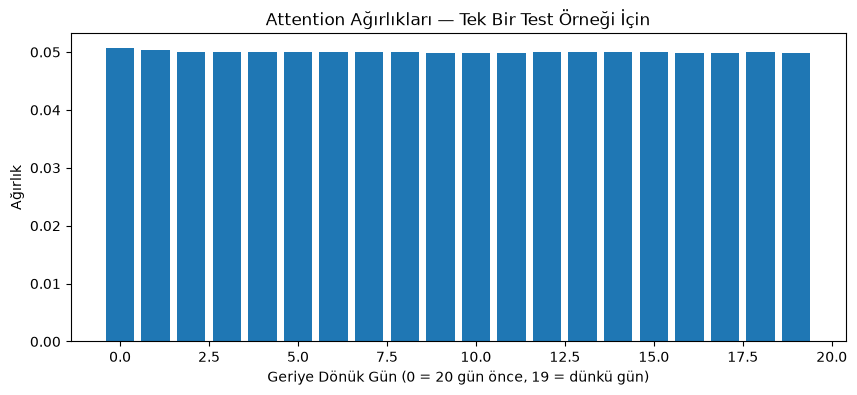

In [45]:
attn_model.eval()
with torch.no_grad():
    attn_pred, attn_weights = attn_model(X_test_mt, return_attention=True)

attn_pred_inv = inverse_transform_target(attn_pred.numpy(), multi_scaler, TARGET_COL, input_size)
attn_rmse = np.sqrt(mean_squared_error(y_test_m_inv, attn_pred_inv))
print(f"Attention LSTM Test RMSE: {attn_rmse:.6f}")

# Modelin bir tahmin yaparken son 20 güne nasıl "ağırlık" verdiğini görselleştir
plt.figure(figsize=(10, 4))
plt.bar(range(WINDOW_SIZE), attn_weights[0].numpy())
plt.title('Attention Ağırlıkları — Tek Bir Test Örneği İçin')
plt.xlabel('Geriye Dönük Gün (0 = 20 gün önce, 19 = dünkü gün)')
plt.ylabel('Ağırlık')
plt.show()

In [46]:
import copy

def train_with_early_stopping(model, X_train, y_train, X_val, y_val,
                                num_epochs=300, lr=0.01, patience=15):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        scheduler.step(val_loss)
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}: train={loss.item():.6f} val={val_loss:.6f} lr={optimizer.param_groups[0]['lr']:.6f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping: epoch {epoch+1} (en iyi val_loss={best_val_loss:.6f})")
            break

    model.load_state_dict(best_state)
    return model, history

Early stopping: epoch 17 (en iyi val_loss=0.007178)
Early Stopping + LR Scheduling GRU Test RMSE: 0.019364


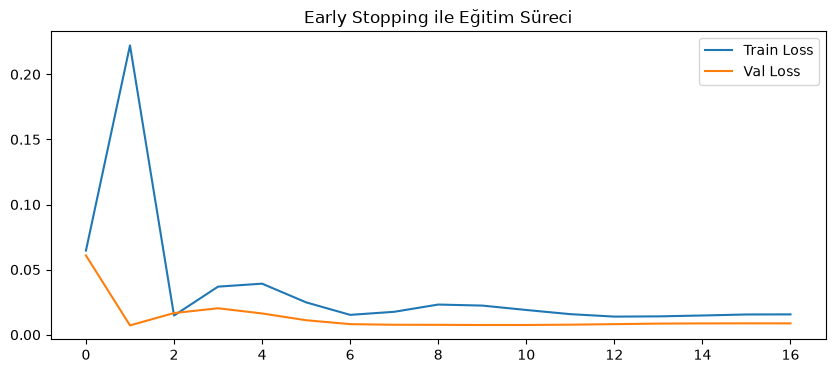

In [47]:
# Train'i train/val olarak ayır (kronolojik, son %15 val)
val_split = int(len(X_train_mt) * 0.85)
X_tr2, X_val2 = X_train_mt[:val_split], X_train_mt[val_split:]
y_tr2, y_val2 = y_train_mt[:val_split], y_train_mt[val_split:]

es_gru = GRUModelV2(input_size=input_size, hidden_size=64, dropout=0.2)
es_gru, history = train_with_early_stopping(es_gru, X_tr2, y_tr2, X_val2, y_val2,
                                              num_epochs=300, patience=15)

es_gru.eval()
with torch.no_grad():
    es_pred = es_gru(X_test_mt)
es_pred_inv = inverse_transform_target(es_pred.numpy(), multi_scaler, TARGET_COL, input_size)
es_rmse = np.sqrt(mean_squared_error(y_test_m_inv, es_pred_inv))
print(f"Early Stopping + LR Scheduling GRU Test RMSE: {es_rmse:.6f}")

# Loss eğrisi
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Early Stopping ile Eğitim Süreci')
plt.show()

In [48]:
def walk_forward_validation(raw_data, n_folds=4, window_size=20,
                              target_col_idx=5, hidden_size=64, epochs=100, lr=0.01):
    n = len(raw_data)
    fold_size = n // (n_folds + 1)
    results = []

    for fold in range(n_folds):
        train_end = fold_size * (fold + 1)
        test_end = min(fold_size * (fold + 2), n)

        train_raw, test_raw = raw_data[:train_end], raw_data[train_end:test_end]
        if len(test_raw) <= window_size:
            continue

        scaler = MinMaxScaler(feature_range=(-1, 1))
        train_scaled = scaler.fit_transform(train_raw)
        test_scaled = scaler.transform(test_raw)

        X_tr, y_tr = create_sequences_multi(train_scaled, window_size, target_col_idx)
        X_te, y_te = create_sequences_multi(test_scaled, window_size, target_col_idx)
        X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)
        X_te_t, y_te_t = torch.FloatTensor(X_te), torch.FloatTensor(y_te)

        model = GRUModelV2(input_size=X_tr_t.shape[2], hidden_size=hidden_size, dropout=0.2)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        for epoch in range(epochs):
            model.train()
            opt.zero_grad()
            loss = criterion(model(X_tr_t), y_tr_t)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(X_te_t)
        pred_inv = inverse_transform_target(pred.numpy(), scaler, target_col_idx, X_tr_t.shape[2])
        y_te_inv = inverse_transform_target(y_te_t.numpy(), scaler, target_col_idx, X_tr_t.shape[2])
        rmse = np.sqrt(mean_squared_error(y_te_inv, pred_inv))

        results.append({'fold': fold+1, 'train_size': len(train_raw), 'rmse': rmse})
        print(f"Fold {fold+1}: train_size={len(train_raw)} RMSE={rmse:.6f}")

    return results

wf_results = walk_forward_validation(data_multi, n_folds=4, window_size=WINDOW_SIZE,
                                       target_col_idx=TARGET_COL, epochs=100)
wf_rmses = [r['rmse'] for r in wf_results]
print(f"\nWalk-forward ortalama RMSE: {np.mean(wf_rmses):.6f} (+/- {np.std(wf_rmses):.6f})")

Fold 1: train_size=603 RMSE=0.036703
Fold 2: train_size=1206 RMSE=0.021712
Fold 3: train_size=1809 RMSE=0.019798
Fold 4: train_size=2412 RMSE=0.016899

Walk-forward ortalama RMSE: 0.023778 (+/- 0.007656)


In [49]:
def prepare_stock_multi(df, name, window_size, target_col_idx, train_split=0.8):
    stock = df[df['Name'] == name].copy().sort_values('Date').reset_index(drop=True)
    feats = ['Open', 'High', 'Low', 'Close', 'Volume']
    stock_multi = stock[feats].copy()
    stock_multi['Return'] = stock['Close'].pct_change()
    stock_multi = stock_multi.dropna().reset_index(drop=True)
    data = stock_multi.values

    train_size = int(len(data) * train_split)
    train_raw, test_raw = data[:train_size], data[train_size:]

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled = scaler.transform(test_raw)

    X_tr, y_tr = create_sequences_multi(train_scaled, window_size, target_col_idx)
    X_te, y_te = create_sequences_multi(test_scaled, window_size, target_col_idx)

    return {
        'X_train': torch.FloatTensor(X_tr), 'y_train': torch.FloatTensor(y_tr),
        'X_test': torch.FloatTensor(X_te), 'y_test': torch.FloatTensor(y_te),
        'scaler': scaler
    }

# İstediğin başka bir hisseyi seç (veri setindeki 'Name' kolonunda hangileri var, kontrol et)
print(df['Name'].unique())

<StringArray>
[  'MMM',   'AXP',  'AAPL',    'BA',   'CAT',   'CVX',  'CSCO',    'KO',
   'DIS',   'XOM',    'GE',    'GS',    'HD',   'IBM',  'INTC',   'JNJ',
   'JPM',   'MCD',   'MRK',  'MSFT',   'NKE',   'PFE',    'PG',   'TRV',
   'UTX',   'UNH',    'VZ',   'WMT', 'GOOGL',  'AMZN',  'AABA']
Length: 31, dtype: str


In [50]:
OTHER_STOCK = 'GOOGL'   # veri setinde var olan başka bir hisse ismiyle değiştir
other_data = prepare_stock_multi(df, OTHER_STOCK, WINDOW_SIZE, TARGET_COL)

# AMZN'de eğitilmiş gru_v2 modelini, hiç yeniden eğitmeden diğer hisseye uygula
gru_v2.eval()
with torch.no_grad():
    cross_pred = gru_v2(other_data['X_test'])
cross_pred_inv = inverse_transform_target(cross_pred.numpy(), other_data['scaler'], TARGET_COL, input_size)
other_y_inv = inverse_transform_target(other_data['y_test'].numpy(), other_data['scaler'], TARGET_COL, input_size)
cross_rmse = np.sqrt(mean_squared_error(other_y_inv, cross_pred_inv))
print(f"AMZN'de eğitilen model -> {OTHER_STOCK} test RMSE: {cross_rmse:.6f}")

# Referans: aynı mimariyi OTHER_STOCK'un kendi verisiyle sıfırdan eğit
native_model = GRUModelV2(input_size=input_size, hidden_size=64, dropout=0.2)
opt = torch.optim.Adam(native_model.parameters(), lr=0.01)
for epoch in range(200):
    native_model.train()
    opt.zero_grad()
    loss = criterion(native_model(other_data['X_train']), other_data['y_train'])
    loss.backward()
    opt.step()

native_model.eval()
with torch.no_grad():
    native_pred = native_model(other_data['X_test'])
native_pred_inv = inverse_transform_target(native_pred.numpy(), other_data['scaler'], TARGET_COL, input_size)
native_rmse = np.sqrt(mean_squared_error(other_y_inv, native_pred_inv))
print(f"{OTHER_STOCK}'un kendi verisiyle eğitilen model -> {OTHER_STOCK} test RMSE: {native_rmse:.6f}")

print(f"\n=== Genelleme Karşılaştırması ===")
print(f"AMZN modeli (transfer)  -> {OTHER_STOCK}: {cross_rmse:.6f}")
print(f"{OTHER_STOCK} native model -> {OTHER_STOCK}: {native_rmse:.6f}")

AMZN'de eğitilen model -> GOOGL test RMSE: 0.030056
GOOGL'un kendi verisiyle eğitilen model -> GOOGL test RMSE: 0.011734

=== Genelleme Karşılaştırması ===
AMZN modeli (transfer)  -> GOOGL: 0.030056
GOOGL native model -> GOOGL: 0.011734
